(40, 349, 2)


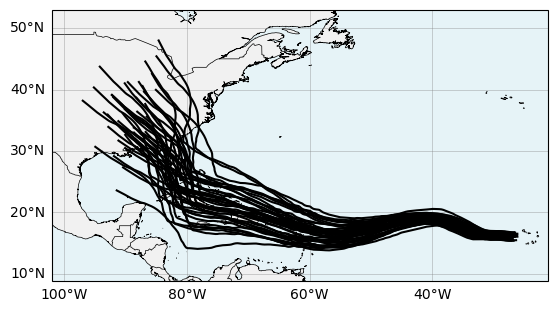

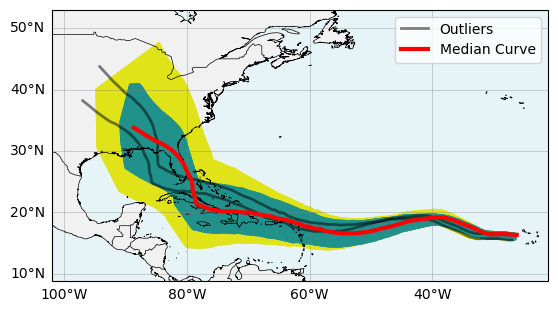

In [8]:

# Import necessary libraries and load dataset
from uvisbox.Modules.CurveBoxplot import curve_boxplot
from uvisbox.Core.CommonInterface import BoxplotStyleConfig

from uvisbox.Datasets import irma2017_perturbed_tracks
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

def load_irma_data():
    data = irma2017_perturbed_tracks.load_dataset()
    print(data.shape)
    return data

def setup_figure(data):
    # Set the extent of the map to the region of interest
    lon_min = np.min(data[:, :, 0])
    lon_max = np.max(data[:, :, 0])
    lat_min = np.min(data[:, :, 1])
    lat_max = np.max(data[:, :, 1])
    # Add some padding to the extent
    padding = 5.0

    # create a figure with 2 subplots  
    fig1, ax1 = plt.subplots(1, 1, subplot_kw={'projection': ccrs.PlateCarree()})
    ax1.set_extent([lon_min - padding, lon_max + padding, 
                    lat_min - padding, lat_max + padding], 
                crs=ccrs.PlateCarree())
    # Add coastlines and country borders
    ax1.coastlines(resolution='10m', linewidth=0.5)
    ax1.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
    ax1.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax1.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)

    # Add gridlines with only latitude and longitude labels
    gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
    gl1.top_labels = False
    gl1.right_labels = False
    gl1.xlabel_style = {'size': 10}
    gl1.ylabel_style = {'size': 10}

    return fig1, ax1



data = load_irma_data()

fig1, ax1 = setup_figure(data)
# plot all curves in light gray
for curve in data:
    ax1.plot(curve[:, 0], curve[:, 1], color='black', alpha=1.0, transform=ccrs.PlateCarree())


# Create custom styling configuration
style = BoxplotStyleConfig(
    percentiles=[95, 50],
    percentile_colormap='viridis', 
    show_median=True,
    median_color='red',
    show_outliers=True,
    outliers_color='black',
    outliers_width= 2
)

fig2, ax2 = setup_figure(data)
# Call the curve_boxplot function 
curve_boxplot(data, boxplot_style=style, ax=ax2)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)


fig1.savefig("irma_all_tracks.png", dpi=150, bbox_inches='tight')
fig2.savefig("irma_curve_boxplot.png", dpi=150, bbox_inches='tight')

plt.show()